In [1]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.abspath('..'))  # on est dans notebooks/

In [ ]:
# Ajoute la racine du projet et importe les modules/fonctions utiles
import sys, os
from pathlib import Path

import numpy as np
pi = np.pi
from scipy.interpolate import UnivariateSpline
from scipy.integrate import simpson
from scipy.integrate import trapezoid, cumulative_trapezoid
from matplotlib import pyplot as plt
import pandas as pd
import pycraf
from pycraf import conversions as cnv
from astropy import units as u

# import pratique - atm_tools
from src.cosmo_lidar.atm_tools import (
    effective_area_and_waist,
    alpha_specific_function,
    optical_depth_emission,
    contribution_effective_area,
    Calcul_T_sky_1_el,
    calcul_PWV,
    calcul_z_percentile_wvc,
    vapor_pressure,
    mass_quantile_grid,
    pwv_profile,
    Calcul_T_sky_Slab_RJ,
)

In [3]:
#pycraf grid
frq = np.arange(80,1000,2) #GHz

altitudes = np.geomspace(1, 25000, 1000) #m
altitudes = altitudes +4999 #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa

In [10]:
frequency = frq * 1e9 #Hz

In [4]:
Tatm_pycraf_old_calc = Calcul_T_sky_1_el(frq*10**9, altitudes, Temperature, Pressure, P_water, 90)

Tatm_pycraf_new_calc = Calcul_T_sky_Slab_RJ(frq*10**9, altitudes, Temperature, Pressure, P_water, 90)

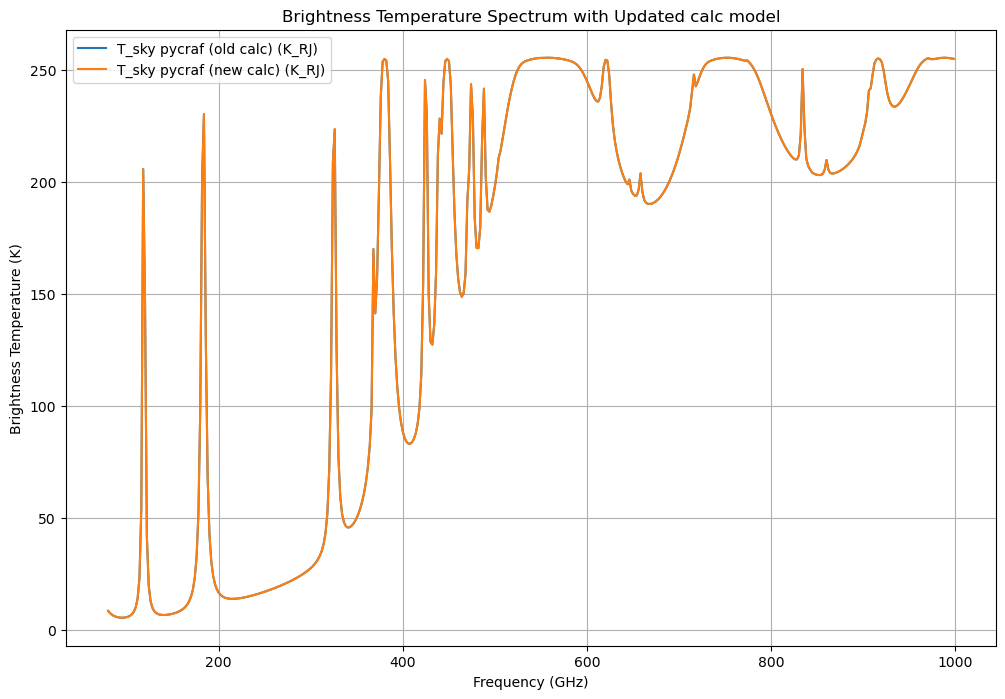

In [5]:
plt.figure(figsize=(12,8))
plt.plot(frq, Tatm_pycraf_old_calc, label='T_sky pycraf (old calc) (K_RJ)')
plt.plot(frq, Tatm_pycraf_new_calc, label='T_sky pycraf (new calc) (K_RJ)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum with Updated calc model')
plt.legend()
plt.grid()
plt.show()

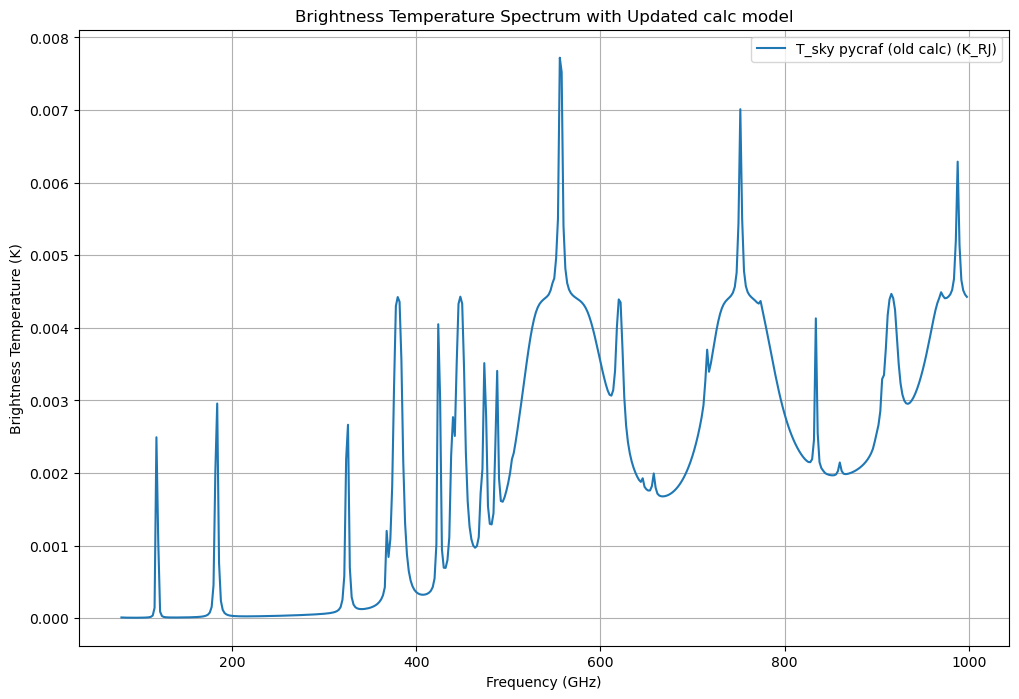

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(frq, Tatm_pycraf_old_calc - Tatm_pycraf_new_calc, label='T_sky pycraf (old calc - new) (K_RJ)')
#plt.plot(frq, Tatm_pycraf_new_calc, label='T_sky pycraf (new calc) (K_RJ)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum with Updated calc model')
plt.legend()
plt.grid()
plt.show()

comparison with a bad grid

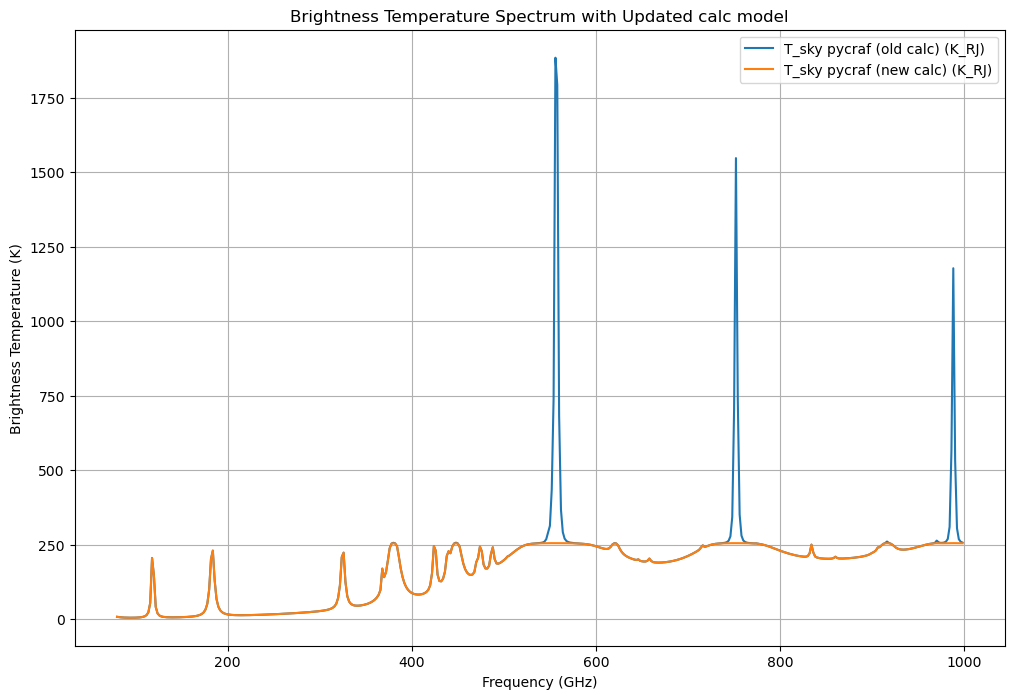

In [66]:
#pycraf grid
frq = np.arange(80,1000,2) #GHz

#altitudes = np.geomspace(1, 25000, 1000) #m
#altitudes = altitudes +4999 #m

altitudes = np.arange(5000, 30000, 25) #m

altitudes_km = altitudes * u.m       # maintenant c'est une Quantity en m
altitudes_km = altitudes_km.to(u.km) # conversion en km
Temperature = pycraf.atm.profile_standard(altitudes_km)[0].value #en K
Pressure = pycraf.atm.profile_standard(altitudes_km)[1].value #en hPa
rho_water = pycraf.atm.profile_standard(altitudes_km)[2].value #en g/m3
P_water = pycraf.atm.profile_standard(altitudes_km)[3].value #en hPa

frequency = frq * 1e9 #Hz

Tatm_pycraf_old_calc = Calcul_T_sky_1_el(frq*10**9, altitudes, Temperature, Pressure, P_water, 90)

Tatm_pycraf_new_calc = Calcul_T_sky_Slab_RJ(frq*10**9, altitudes, Temperature, Pressure, P_water, 90)


plt.figure(figsize=(12,8))
plt.plot(frq, Tatm_pycraf_old_calc, label='T_sky pycraf (old calc) (K_RJ)')
plt.plot(frq, Tatm_pycraf_new_calc, label='T_sky pycraf (new calc) (K_RJ)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum with Updated calc model')
plt.legend()
plt.grid()
plt.show()

In [65]:
from src.cosmo_lidar.atm_tools import Calcul_T_sky_1_el_bb, planck_source

In [62]:
T_atm_pycraf_bb = Calcul_T_sky_1_el_bb(frq*1e9, altitudes, Temperature, Pressure, P_water, 90) # in K_RJ using the blackbody function

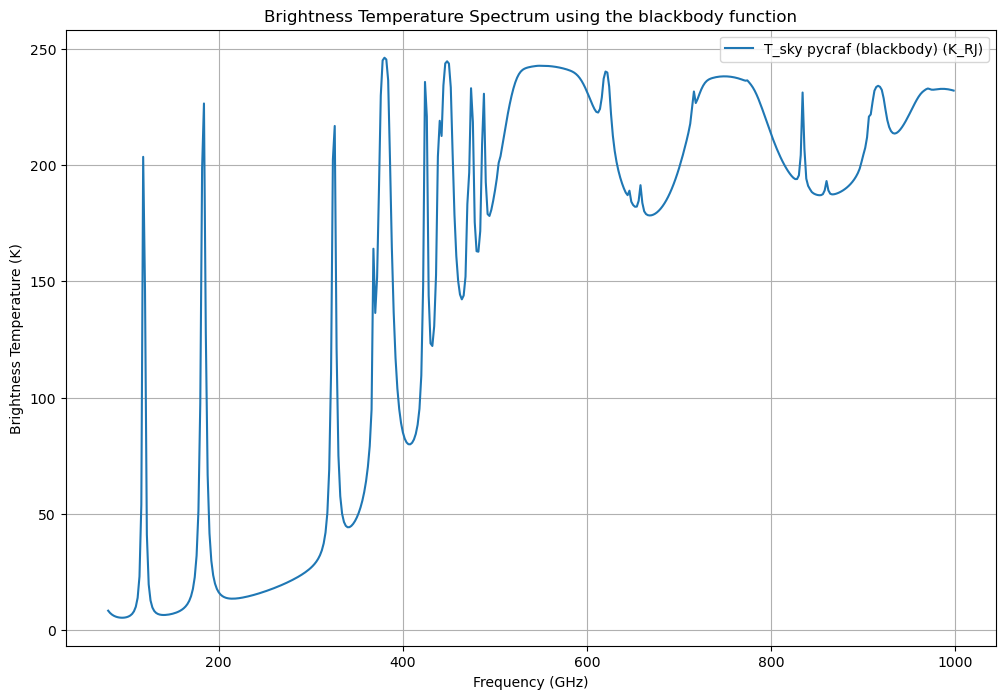

In [63]:
plt.figure(figsize=(12, 8))
plt.plot(frq, T_atm_pycraf_bb, label='T_sky pycraf (blackbody) (K_RJ)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum using the blackbody function')
plt.legend()
plt.grid()
plt.show()

new model with bb model

In [67]:
from src.cosmo_lidar.atm_tools import Calcul_T_sky_Slab_bb

T_atm_pycraf_slab_bb = Calcul_T_sky_Slab_bb(frq*1e9, altitudes, Temperature, Pressure, P_water, 90) # in K_RJ using the blackbody function

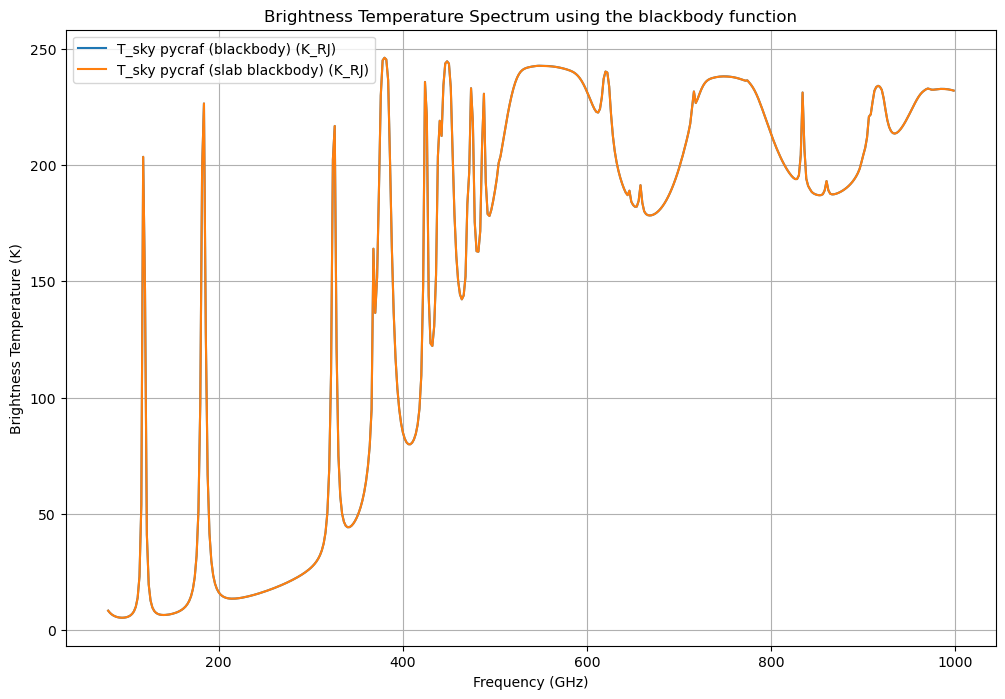

In [68]:
plt.figure(figsize=(12, 8))
plt.plot(frq, T_atm_pycraf_bb, label='T_sky pycraf (blackbody) (K_RJ)')
plt.plot(frq, T_atm_pycraf_slab_bb, label='T_sky pycraf (slab blackbody) (K_RJ)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum using the blackbody function')
plt.legend()
plt.grid()
plt.show()

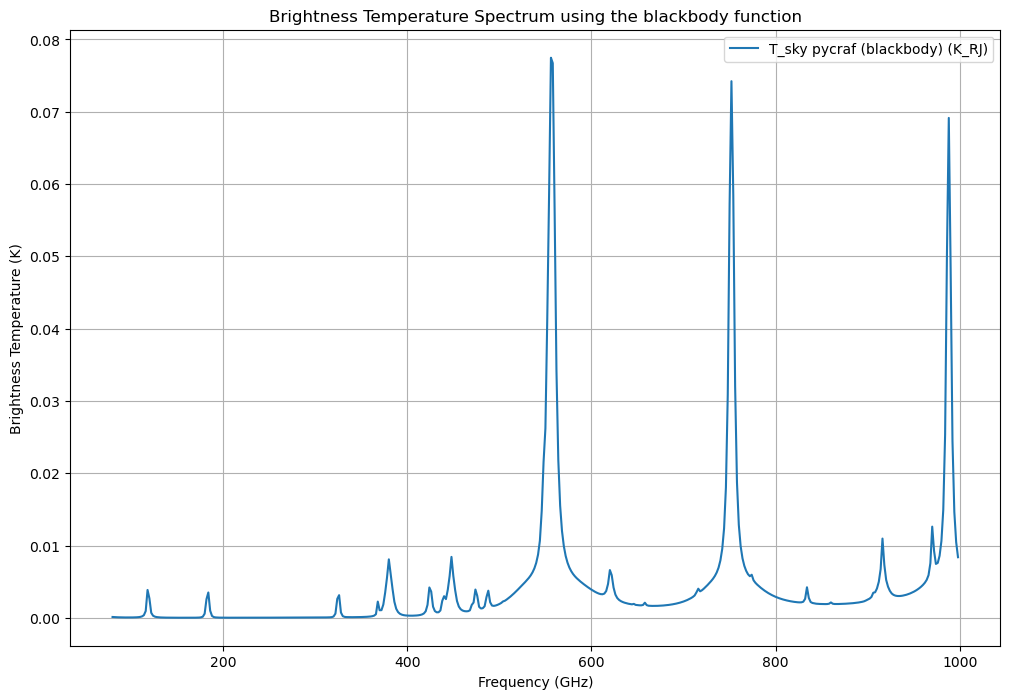

In [69]:
plt.figure(figsize=(12, 8))
plt.plot(frq, T_atm_pycraf_bb - T_atm_pycraf_slab_bb, label='T_sky pycraf (blackbody) (K_RJ)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Brightness Temperature (K)')
plt.title('Brightness Temperature Spectrum using the blackbody function')
plt.legend()
plt.grid()
plt.show()